In [28]:
!pip install xgboost imbalanced-learn shap

In [29]:
!pip install kaggle

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import ttest_ind, chi2_contingency
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [62]:
from google.colab import files
uploaded = files.upload()  # Upload BankChurners.csv when prompted

df = pd.read_csv('BankChurners.csv')

# Drop last 2 irrelevant columns
df = df.iloc[:, :-2]

print("Shape:", df.shape)
df.head()


Shape: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [70]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10127, 21)


In [71]:
print("\nColumn Names:\n", df.columns.tolist())


Column Names:
 ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [72]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


In [73]:
print("\nChurn Distribution:\n", df['Attrition_Flag'].value_counts())


Churn Distribution:
 Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [74]:
# Churn rate
churn_rate = df['Attrition_Flag'].value_counts(normalize=True) * 100
print("\nChurn Rate %:\n", churn_rate)


Churn Rate %:
 Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


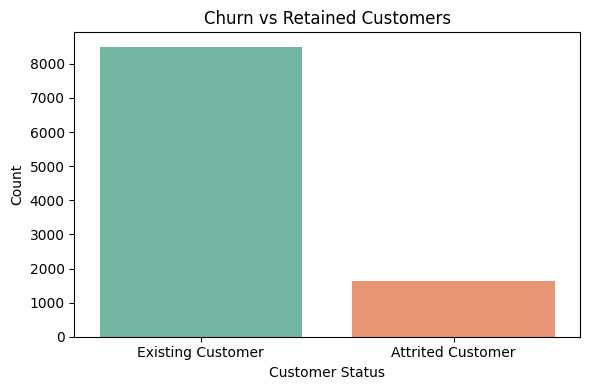

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition_Flag', data=df, palette='Set2')
plt.title('Churn vs Retained Customers')
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

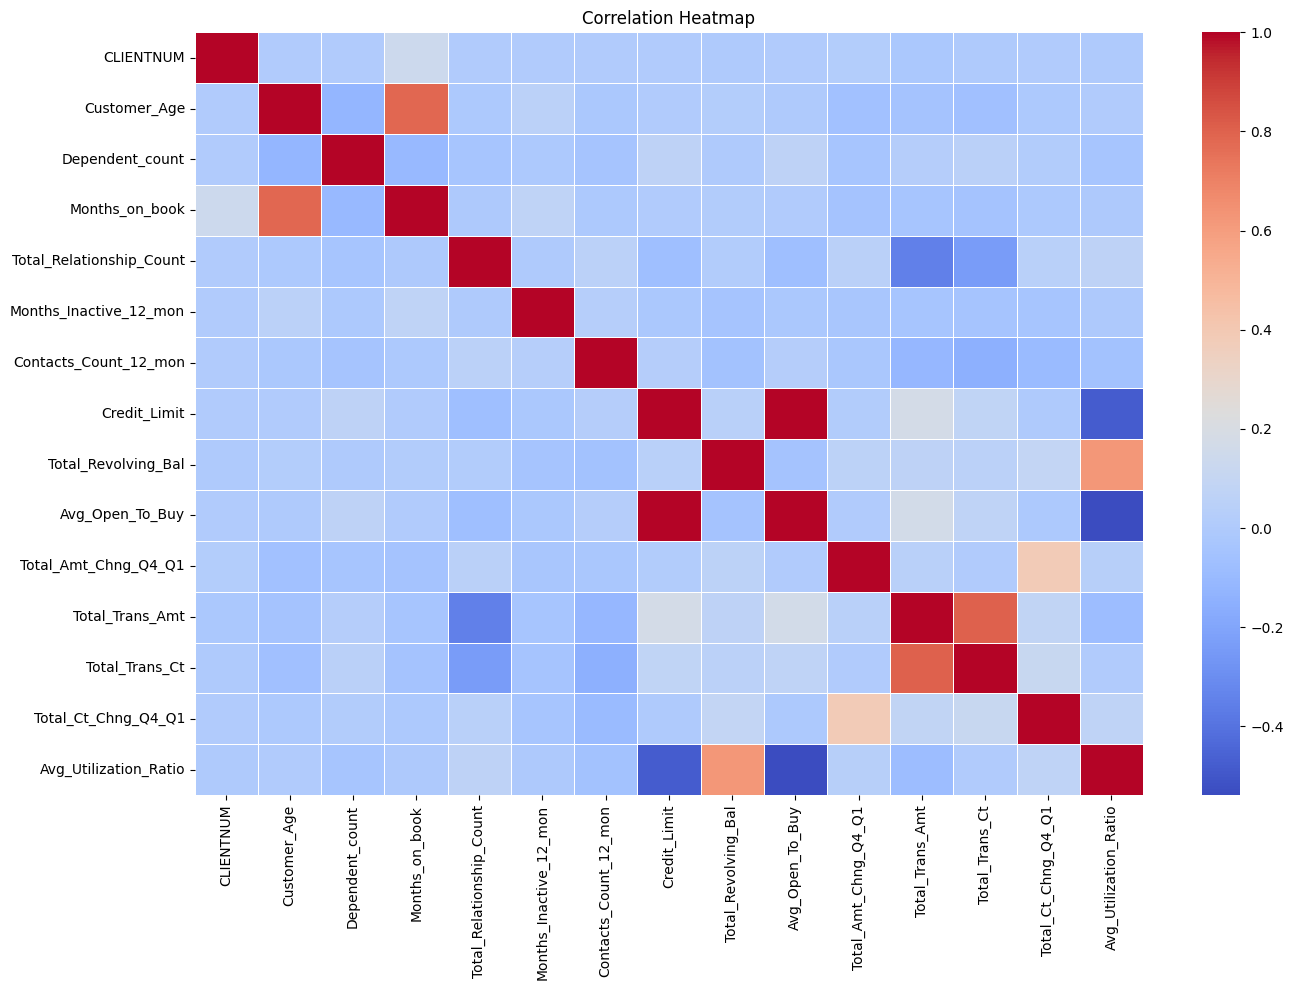

In [76]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [77]:
# Chi-square test on categorical columns
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status',
                    'Income_Category', 'Card_Category']

print("=== Chi-Square Test Results ===")
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['Attrition_Flag'])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f} {'*** Significant' if p < 0.05 else ''}")

# T-test on numerical columns
numerical_cols = ['Customer_Age', 'Total_Trans_Ct', 'Total_Trans_Amt',
                  'Total_Revolving_Bal', 'Months_Inactive_12_mon']

print("\n=== T-Test Results ===")
churned = df[df['Attrition_Flag'] == 'Attrited Customer']
retained = df[df['Attrition_Flag'] == 'Existing Customer']

for col in numerical_cols:
    t_stat, p_val = ttest_ind(churned[col], retained[col])
    print(f"{col}: t={t_stat:.2f}, p-value={p_val:.4f} {'*** Significant' if p_val < 0.05 else ''}")

=== Chi-Square Test Results ===
Gender: chi2=13.87, p-value=0.0002 *** Significant
Education_Level: chi2=12.51, p-value=0.0515 
Marital_Status: chi2=6.06, p-value=0.1089 
Income_Category: chi2=12.83, p-value=0.0250 *** Significant
Card_Category: chi2=2.23, p-value=0.5252 

=== T-Test Results ===
Customer_Age: t=1.83, p-value=0.0670 
Total_Trans_Ct: t=-40.25, p-value=0.0000 *** Significant
Total_Trans_Amt: t=-17.21, p-value=0.0000 *** Significant
Total_Revolving_Bal: t=-27.44, p-value=0.0000 *** Significant
Months_Inactive_12_mon: t=15.52, p-value=0.0000 *** Significant


In [78]:
# Create new behavioral precursor features
df['Avg_Txn_Per_Month'] = df['Total_Trans_Ct'] / df['Months_on_book']
df['Balance_Utilization'] = df['Total_Revolving_Bal'] / (df['Credit_Limit'] + 1)
df['Avg_Txn_Amount'] = df['Total_Trans_Amt'] / (df['Total_Trans_Ct'] + 1)
df['Inactivity_Rate'] = df['Months_Inactive_12_mon'] / 12

print("New features created successfully!")
df[['Avg_Txn_Per_Month', 'Balance_Utilization',
    'Avg_Txn_Amount', 'Inactivity_Rate']].describe()

New features created successfully!


,Avg_Txn_Per_Month,Balance_Utilization,Avg_Txn_Amount,Inactivity_Rate
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,1.923120,0.274796,61.573946,0.195097
std,0.911977,0.275570,26.244708,0.084219
min,0.188679,0.000000,18.813559,0.000000
25%,1.272727,0.022713,46.509259,0.166667
50%,1.857143,0.175613,54.857143,0.166667
75%,2.361111,0.502524,64.327076,0.250000
max,9.769231,0.998358,188.056180,0.500000


In [79]:

# Encode target
df['Churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Encode categoricals
le = LabelEncoder()
for col in ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']:
    df[col] = le.fit_transform(df[col])

# Final features
X = df.drop(['Attrition_Flag', 'Churn'], axis=1)
y = df['Churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Features:", X.columns.tolist())
print("Shape:", X.shape)
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Features: ['CLIENTNUM', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Txn_Per_Month', 'Balance_Utilization', 'Avg_Txn_Amount', 'Inactivity_Rate']
Shape: (10127, 24)
After SMOTE: {0: 6799, 1: 6799}


In [80]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 6799, 1: 1302}
After SMOTE: {0: 6799, 1: 6799}


In [81]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train_sm, y_train_sm)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print("=== Model Comparison ===")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")

=== Model Comparison ===
Logistic Regression AUC: 0.7165
Random Forest AUC:       0.9826
XGBoost AUC:             0.9891


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.90      0.87      0.89       325

    accuracy                           0.96      2026
   macro avg       0.94      0.93      0.93      2026
weighted avg       0.96      0.96      0.96      2026

AUC-ROC Score: 0.9891


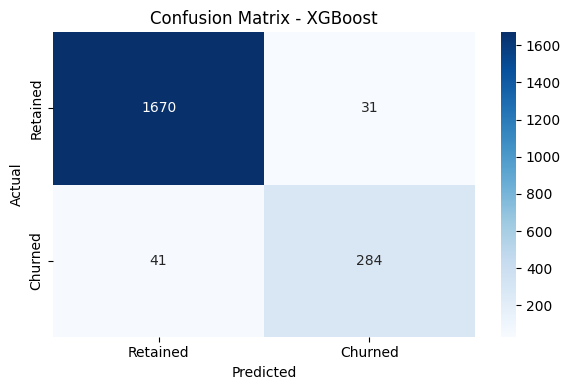

In [82]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

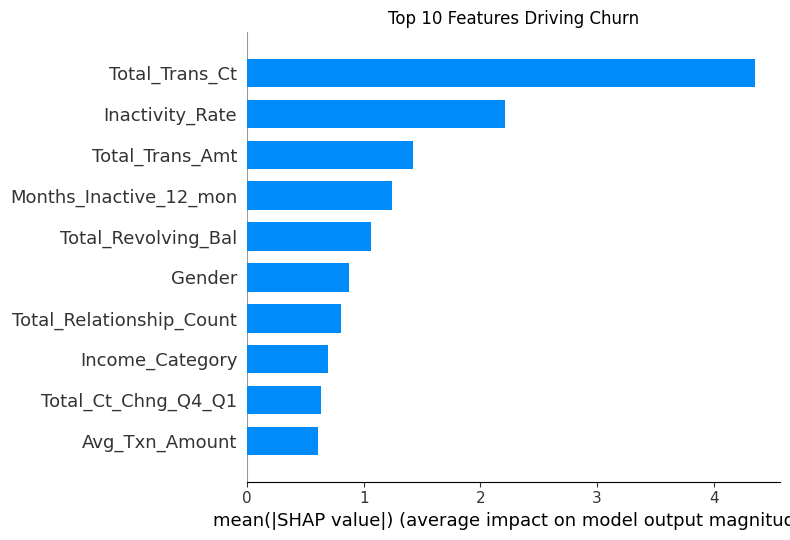

In [83]:
explainer = shap.Explainer(xgb_model, X_train_sm)
shap_values = explainer(X_test[:100])

plt.figure()
shap.summary_plot(shap_values, X_test[:100], plot_type="bar",
                  show=False, max_display=10)
plt.title('Top 10 Features Driving Churn')
plt.tight_layout()
plt.show()

=== Prioritization Tiers ===
Risk_Tier
Low Risk       1662
High Risk       295
Medium Risk      69
Name: count, dtype: int64

Avg Churn Probability per Tier:
Risk_Tier
High Risk      0.968
Low Risk       0.007
Medium Risk    0.419
Name: Churn_Probability, dtype: float32


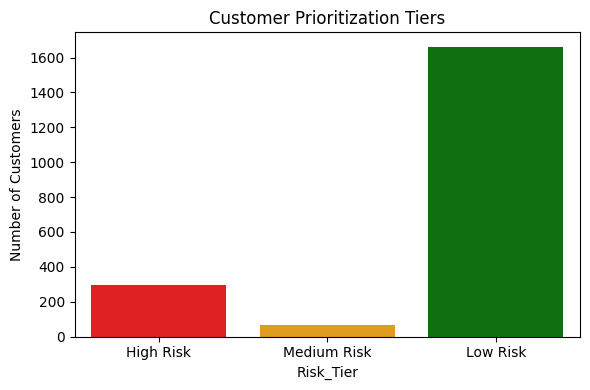

In [84]:
from sklearn.cluster import KMeans

# Add churn probability to dataframe
X_test_copy = X_test.copy()
X_test_copy['Churn_Probability'] = y_prob

# KMeans clustering into 3 tiers
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_test_copy['Tier'] = kmeans.fit_predict(X_test_copy[['Churn_Probability']])

# Sort tiers by churn probability mean
tier_map = X_test_copy.groupby('Tier')['Churn_Probability'].mean().sort_values()
tier_labels = {tier_map.index[0]: 'Low Risk',
               tier_map.index[1]: 'Medium Risk',
               tier_map.index[2]: 'High Risk'}
X_test_copy['Risk_Tier'] = X_test_copy['Tier'].map(tier_labels)

print("=== Prioritization Tiers ===")
print(X_test_copy['Risk_Tier'].value_counts())
print("\nAvg Churn Probability per Tier:")
print(X_test_copy.groupby('Risk_Tier')['Churn_Probability'].mean().round(3))

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Tier', data=X_test_copy,
              order=['High Risk','Medium Risk','Low Risk'],
              palette={'High Risk':'red','Medium Risk':'orange','Low Risk':'green'})
plt.title('Customer Prioritization Tiers')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [85]:
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")
print("Total features:", len(X.columns))

Model saved successfully!
Total features: 24
